# Neural Synthetic Ray Tracing: Learning Scene Priors from Data

We now extend the differentiable ray tracing lessons by building a tiny data-driven prior.
This notebook shows, step by step, how to create a synthetic dataset of rendered spheres,
        compute simple image features, and train a lightweight neural network (implemented from scratch
        in NumPy) to predict scene parameters. The trained network acts as a prior: given a novel image,
        it provides a smart initialization for inverse rendering tasks.

## Roadmap
1. Reuse the pure-Python renderer (camera, rays, Lambertian shading).
2. Generate a small dataset of random scenes (sphere center and light intensity).
3. Extract intuitive image features (center-of-mass, mean color, bias term).
4. Train a from-scratch neural regressor to map features to scene parameters.
5. Evaluate the learned prior and visualize predictions.

## 1. Renderer Setup
We adapt the ray tracer from the earlier notebooks. The renderer exposes a function
        `render_image(center_x, log_intensity, camera)` that returns an RGB image of a red sphere
        lit by a single directional light.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

plt.rcParams['figure.dpi'] = 120
np.set_printoptions(precision=3, suppress=True)

In [2]:
@dataclass
class Ray:
    origin: np.ndarray
    direction: np.ndarray

def unit_vector(v: np.ndarray) -> np.ndarray:
    norm = np.linalg.norm(v)
    return v if norm < 1e-9 else v / norm

@dataclass
class Camera:
    width: int
    height: int
    origin: np.ndarray
    lower_left_corner: np.ndarray
    horizontal: np.ndarray
    vertical: np.ndarray

def make_camera(width: int = 96, height: int = 96, focal_length: float = 1.0) -> Camera:
    aspect = width / height
    viewport_height = 2.0
    viewport_width = aspect * viewport_height
    origin = np.array([0.0, 0.0, -1.0])
    horizontal = np.array([viewport_width, 0.0, 0.0])
    vertical = np.array([0.0, viewport_height, 0.0])
    lower_left_corner = origin + np.array([
        -viewport_width / 2,
        -viewport_height / 2,
        focal_length,
    ])
    return Camera(width, height, origin, lower_left_corner, horizontal, vertical)

def hit_sphere(center: np.ndarray, radius: float, ray: Ray) -> float:
    oc = ray.origin - center
    a = np.dot(ray.direction, ray.direction)
    b = 2.0 * np.dot(oc, ray.direction)
    c = np.dot(oc, oc) - radius ** 2
    discriminant = b ** 2 - 4 * a * c
    if discriminant < 0:
        return -1.0
    sq = np.sqrt(discriminant)
    t = (-b - sq) / (2 * a)
    if t > 0:
        return t
    t = (-b + sq) / (2 * a)
    return t if t > 0 else -1.0

def shade(ray: Ray, center: np.ndarray, radius: float, light_dir: np.ndarray, light_intensity: float) -> np.ndarray:
    t = hit_sphere(center, radius, ray)
    if t < 0:
        unit_dir = unit_vector(ray.direction)
        blend = 0.5 * (unit_dir[1] + 1.0)
        return (1.0 - blend) * np.array([1.0, 1.0, 1.0]) + blend * np.array([0.5, 0.7, 1.0])
    hit_point = ray.origin + t * ray.direction
    normal = unit_vector(hit_point - center)
    lambert = max(np.dot(normal, light_dir), 0.0)
    base = np.array([0.8, 0.2, 0.2])
    ambient = 0.1
    color = (ambient + light_intensity * lambert) * base
    return np.clip(color, 0.0, 1.0)

def render_image(center_x: float, log_intensity: float, camera: Camera, radius: float = 0.5) -> np.ndarray:
    image = np.zeros((camera.height, camera.width, 3), dtype=np.float32)
    sphere_center = np.array([center_x, 0.0, 0.5])
    light_dir = unit_vector(np.array([0.35, 0.55, -1.2]))
    light_intensity = np.exp(log_intensity)
    for j in range(camera.height):
        v = (j + 0.5) / camera.height
        for i in range(camera.width):
            u = (i + 0.5) / camera.width
            direction = (
                camera.lower_left_corner
                + u * camera.horizontal
                + v * camera.vertical
                - camera.origin
            )
            ray = Ray(camera.origin, unit_vector(direction))
            row = camera.height - j - 1
            image[row, i] = shade(ray, sphere_center, radius, light_dir, light_intensity)
    return image

## 2. Synthetic Dataset
We create a dataset by sampling random scene parameters, rendering images, and storing the
        associated ground-truth labels (sphere center and light log-intensity). The dataset mimics
        the data a renderer would produce for supervised pre-training.

In [3]:
def generate_dataset(num_samples: int, camera: Camera, center_range=(-0.35, 0.35), intensity_range=(-1.2, 0.2), seed: int = 0):
    rng = np.random.default_rng(seed)
    centers = rng.uniform(*center_range, size=num_samples)
    log_intensities = rng.uniform(*intensity_range, size=num_samples)
    images = []
    labels = []
    for cx, log_i in zip(centers, log_intensities):
        img = render_image(cx, log_i, camera)
        images.append(img)
        labels.append(np.array([cx, log_i], dtype=np.float32))
    return np.stack(images), np.stack(labels)

camera = make_camera(96, 96)
train_images, train_labels = generate_dataset(48, camera, seed=1)
val_images, val_labels = generate_dataset(16, camera, seed=2025)

print('Dataset shapes: train', train_images.shape, 'val', val_images.shape)

Dataset shapes: train (48, 96, 96, 3) val (16, 96, 96, 3)


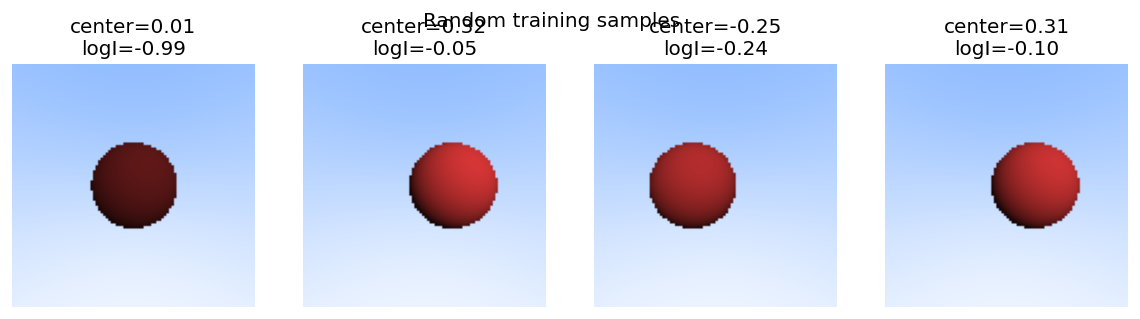

In [5]:
def show_samples(images, labels, num_cols=4):
    num = min(len(images), num_cols)
    fig, axes = plt.subplots(1, num, figsize=(3 * num, 3))
    for ax, img, label in zip(np.atleast_1d(axes), images[:num], labels[:num]):
        ax.imshow(img)
        ax.set_title(f'center={label[0]:.2f}\nlogI={label[1]:.2f}')
        ax.axis('off')
    fig.suptitle('Random training samples')
    plt.show()

show_samples(train_images, train_labels)

## 3. Feature Extraction and Neural Prior
To keep the example simple, we summarize each image with intuitive statistics: center of mass
        in normalized coordinates, mean RGB color, and a bias term. These features feed a tiny
        two-layer neural network that predicts the sphere center and light log-intensity.

In [6]:
def image_features(image: np.ndarray) -> np.ndarray:
    h, w, _ = image.shape
    ys = np.linspace(1.0, -1.0, h)
    xs = np.linspace(-1.0, 1.0, w)
    grid_x, grid_y = np.meshgrid(xs, ys)
    brightness = image.mean(axis=2)
    mass = brightness / (brightness.sum() + 1e-8)
    x_com = float(np.sum(grid_x * mass))
    y_com = float(np.sum(grid_y * mass))
    color_mean = image.mean(axis=(0, 1))
    variance = float(np.var(image))
    return np.concatenate([np.array([x_com, y_com, variance]), color_mean, np.array([1.0])])

def batch_features(images: np.ndarray) -> np.ndarray:
    return np.stack([image_features(img) for img in images])

train_features = batch_features(train_images)
val_features = batch_features(val_images)
print('Feature dimension:', train_features.shape[1])

Feature dimension: 7


In [7]:
class TinyRegressor:
    def __init__(self, in_dim: int, hidden_dim: int = 16, out_dim: int = 2, seed: int = 0):
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(scale=0.25, size=(hidden_dim, in_dim))
        self.b1 = np.zeros(hidden_dim)
        self.W2 = rng.normal(scale=0.25, size=(out_dim, hidden_dim))
        self.b2 = np.zeros(out_dim)

    def forward(self, x: np.ndarray) -> np.ndarray:
        self.x = x
        self.z1 = self.W1 @ x + self.b1
        self.h = np.tanh(self.z1)
        self.z2 = self.W2 @ self.h + self.b2
        return self.z2.copy()

    def backward(self, grad_output: np.ndarray):
        grad_W2 = np.outer(grad_output, self.h)
        grad_b2 = grad_output
        grad_h = self.W2.T @ grad_output
        grad_z1 = grad_h * (1.0 - self.h ** 2)
        grad_W1 = np.outer(grad_z1, self.x)
        grad_b1 = grad_z1
        return grad_W1, grad_b1, grad_W2, grad_b2

    def apply_updates(self, grads, lr: float):
        grad_W1, grad_b1, grad_W2, grad_b2 = grads
        self.W1 -= lr * grad_W1
        self.b1 -= lr * grad_b1
        self.W2 -= lr * grad_W2
        self.b2 -= lr * grad_b2

model = TinyRegressor(train_features.shape[1], hidden_dim=16, out_dim=2, seed=7)

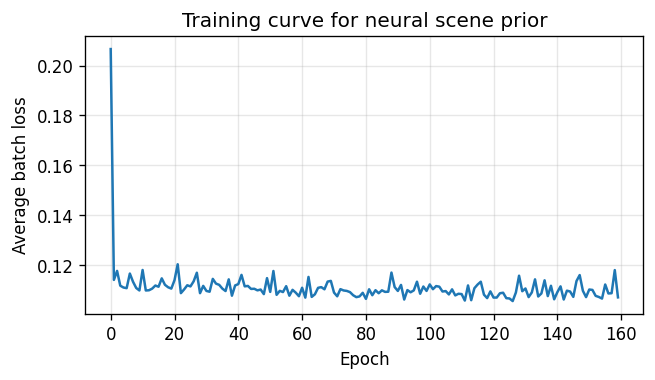

In [8]:
def train(model, features, targets, epochs=200, batch_size=8, lr=0.08, seed=0):
    rng = np.random.default_rng(seed)
    losses = []
    n = len(features)
    for epoch in range(epochs):
        indices = rng.permutation(n)
        epoch_loss = 0.0
        for start in range(0, n, batch_size):
            batch_idx = indices[start:start + batch_size]
            grad_W1 = np.zeros_like(model.W1)
            grad_b1 = np.zeros_like(model.b1)
            grad_W2 = np.zeros_like(model.W2)
            grad_b2 = np.zeros_like(model.b2)
            batch_loss = 0.0
            for idx in batch_idx:
                x = features[idx]
                y = targets[idx]
                pred = model.forward(x)
                diff = pred - y
                batch_loss += 0.5 * np.sum(diff ** 2)
                grads = model.backward(diff)
                grad_W1 += grads[0]
                grad_b1 += grads[1]
                grad_W2 += grads[2]
                grad_b2 += grads[3]
            scale = 1.0 / len(batch_idx)
            model.apply_updates((grad_W1 * scale, grad_b1 * scale, grad_W2 * scale, grad_b2 * scale), lr)
            epoch_loss += batch_loss * scale
        losses.append(epoch_loss / (n / batch_size))
    return losses

train_losses = train(model, train_features, train_labels, epochs=160, batch_size=8, lr=0.07, seed=5)
plt.figure(figsize=(6, 3))
plt.plot(train_losses, color='tab:blue')
plt.xlabel('Epoch')
plt.ylabel('Average batch loss')
plt.title('Training curve for neural scene prior')
plt.grid(alpha=0.3)
plt.show()

Validation MAE center: 0.213, log-intensity: 0.327


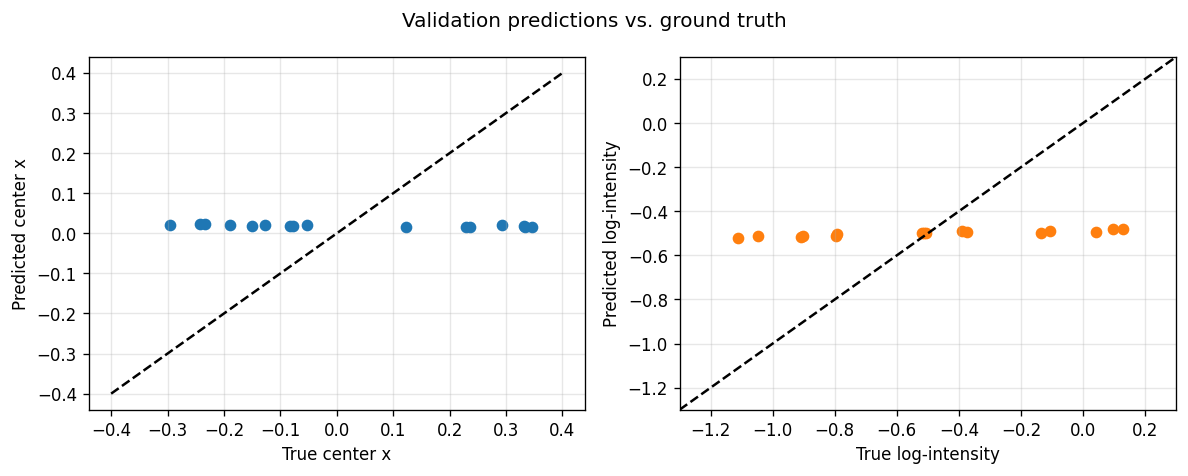

In [9]:
def predict(model, features):
    return np.stack([model.forward(x) for x in features])

val_preds = predict(model, val_features)
center_mae = np.mean(np.abs(val_preds[:, 0] - val_labels[:, 0]))
intensity_mae = np.mean(np.abs(val_preds[:, 1] - val_labels[:, 1]))
print(f'Validation MAE center: {center_mae:.3f}, log-intensity: {intensity_mae:.3f}')

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(val_labels[:, 0], val_preds[:, 0], color='tab:blue')
ax[0].plot([-0.4, 0.4], [-0.4, 0.4], 'k--')
ax[0].set_xlabel('True center x')
ax[0].set_ylabel('Predicted center x')
ax[0].grid(alpha=0.3)

ax[1].scatter(val_labels[:, 1], val_preds[:, 1], color='tab:orange')
lims = [-1.3, 0.3]
ax[1].plot(lims, lims, 'k--')
ax[1].set_xlim(lims)
ax[1].set_ylim(lims)
ax[1].set_xlabel('True log-intensity')
ax[1].set_ylabel('Predicted log-intensity')
ax[1].grid(alpha=0.3)
fig.suptitle('Validation predictions vs. ground truth')
plt.tight_layout()
plt.show()

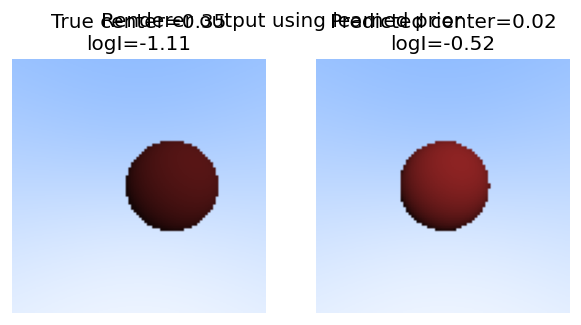

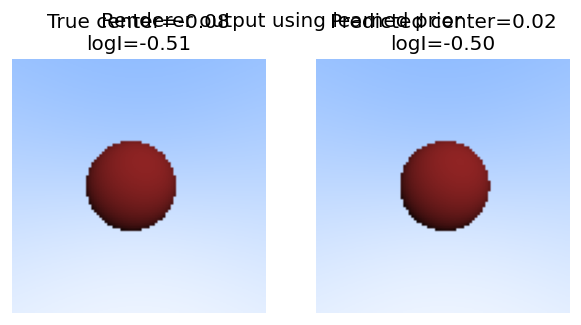

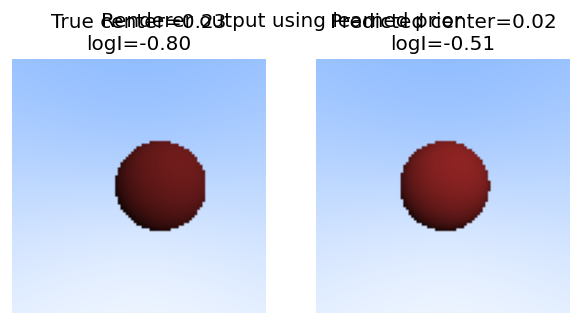

In [11]:
def compare_prediction(image, label, pred, camera):
    recon = render_image(pred[0], pred[1], camera)
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    axes[0].imshow(image)
    axes[0].set_title(f'True center={label[0]:.2f}\nlogI={label[1]:.2f}')
    axes[0].axis('off')
    axes[1].imshow(recon)
    axes[1].set_title(f'Predicted center={pred[0]:.2f}\nlogI={pred[1]:.2f}')
    axes[1].axis('off')
    plt.suptitle('Renderer output using learned prior')
    plt.show()

for idx in range(3):
    compare_prediction(val_images[idx], val_labels[idx], val_preds[idx], camera)